In [ ]:
!pip install --upgrade numpy scipy scikit-learn --quiet
!pip install facenet-pytorch --quiet
!pip install matplotlib seaborn --quiet

import torch
import timm
import cv2
import os
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
from facenet_pytorch import MTCNN
from sklearn.metrics import accuracy_score, precision_recall_fscore_support, confusion_matrix

from google.colab import drive
drive.mount('/content/drive')

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device: {device}")

Mounted at /content/drive
Device: cuda
Model berhasil di-load, siap untuk inferensi.


In [ ]:
SAVE_DIR = '/content/drive/MyDrive/gemastik_deepfake'

model = timm.create_model('efficientnet_b4', pretrained=False, num_classes=2)
model.load_state_dict(torch.load(f'{SAVE_DIR}/model_final_efficientnet_b4.pth', map_location=device))
model = model.to(device)
model.eval()
print("Model berhasil di-load, siap untuk inferensi.")

In [ ]:
mtcnn = MTCNN(image_size=224, margin=20, keep_all=False, post_process=False, device=device)

In [ ]:
def extract_faces_from_video(video_path, n_frames=15):
    """Ekstraksi frame dari video, deteksi & crop wajah dengan MTCNN"""
    v_cap = cv2.VideoCapture(video_path)
    v_len = int(v_cap.get(cv2.CAP_PROP_FRAME_COUNT))

    if v_len <= 0:
        v_cap.release()
        return []

    sample_idx = np.linspace(0, v_len - 1, min(n_frames, v_len)).astype(int)

    faces = []
    for i in range(v_len):
        success = v_cap.grab()
        if i in sample_idx:
            success, frame = v_cap.retrieve()
            if not success:
                continue
            frame = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
            frame_pil = Image.fromarray(frame)

            face = mtcnn(frame_pil)
            if face is not None:
                faces.append(face)

    v_cap.release()
    return faces

In [ ]:
def process_folder(folder_path, label):
    """label: 0 = REAL, 1 = FAKE"""
    all_faces_local = []
    all_labels_local = []

    video_files = [f for f in os.listdir(folder_path) if f.endswith(('.mp4', '.mov', '.avi'))]
    print(f"Memproses {len(video_files)} video dari {folder_path}...")

    for vf in video_files:
        video_path = os.path.join(folder_path, vf)
        faces = extract_faces_from_video(video_path)

        if len(faces) == 0:
            print(f"  ⚠️ Tidak ada wajah terdeteksi di: {vf}")
            continue

        for face in faces:
            face_normalized = (face / 255.0 - torch.tensor([0.485, 0.456, 0.406]).view(3,1,1)) / torch.tensor([0.229, 0.224, 0.225]).view(3,1,1)
            all_faces_local.append(face_normalized)
            all_labels_local.append(label)

        print(f"  ✓ {vf}: {len(faces)} wajah terdeteksi")

    return all_faces_local, all_labels_local

In [ ]:
PATH_FAKE = '/content/drive/MyDrive/dataset_lokal_indonesia/fake'
PATH_REAL = '/content/drive/MyDrive/dataset_lokal_indonesia/real'

fake_faces, fake_labels = process_folder(PATH_FAKE, label=1)
real_faces, real_labels = process_folder(PATH_REAL, label=0)

all_faces = fake_faces + real_faces
all_labels = fake_labels + real_labels

print(f"\nTotal wajah dari data lokal: {len(all_faces)}")
print(f"FAKE: {sum(fake_labels)==len(fake_labels) and len(fake_labels) or len(fake_labels)}, REAL: {len(real_labels)}")

In [ ]:
model.eval()
all_preds = []

with torch.no_grad():
    for face_tensor in all_faces:
        face_input = face_tensor.unsqueeze(0).to(device)
        output = model(face_input)
        pred = torch.argmax(output, dim=1).cpu().item()
        all_preds.append(pred)

acc_local = accuracy_score(all_labels, all_preds)
precision_local, recall_local, f1_local, _ = precision_recall_fscore_support(all_labels, all_preds, average='binary')
cm_local = confusion_matrix(all_labels, all_preds)

print("=== HASIL SKENARIO B: GENERALISASI KE DATA LOKAL INDONESIA ===")
print(f"Akurasi: {acc_local:.4f}")
print(f"Presisi: {precision_local:.4f}")
print(f"Recall: {recall_local:.4f}")
print(f"F1-Score: {f1_local:.4f}")
print(f"Confusion Matrix:\n{cm_local}")

with open(f'{SAVE_DIR}/hasil_skenario_B.txt', 'w') as f:
    f.write(f"Akurasi: {acc_local:.4f}\nPresisi: {precision_local:.4f}\nRecall: {recall_local:.4f}\nF1: {f1_local:.4f}\nConfusion Matrix:\n{cm_local}")

Memproses 20 video dari /content/drive/MyDrive/dataset_lokal_indonesia/fake...
  ✓ 1.mp4: 15 wajah terdeteksi
  ✓ 2.mp4: 15 wajah terdeteksi
  ✓ 3.mp4: 13 wajah terdeteksi
  ✓ 4.mp4: 15 wajah terdeteksi
  ✓ 5.mp4: 15 wajah terdeteksi
  ✓ 6.mp4: 14 wajah terdeteksi
  ✓ 8.mp4: 15 wajah terdeteksi
  ✓ 11.mp4: 8 wajah terdeteksi
  ✓ 9.mp4: 15 wajah terdeteksi
  ✓ 7.mp4: 10 wajah terdeteksi
  ✓ 10.mp4: 14 wajah terdeteksi
  ✓ 12.mp4: 14 wajah terdeteksi
  ✓ 13.mp4: 7 wajah terdeteksi
  ✓ 14.mp4: 13 wajah terdeteksi
  ✓ 15.mp4: 10 wajah terdeteksi
  ✓ 16.mp4: 15 wajah terdeteksi
  ✓ 17.mp4: 14 wajah terdeteksi
  ✓ 18.mp4: 15 wajah terdeteksi
  ✓ 19.mp4: 12 wajah terdeteksi
  ✓ 20.mp4: 11 wajah terdeteksi
Memproses 29 video dari /content/drive/MyDrive/dataset_lokal_indonesia/real...
  ✓ 1.mp4: 15 wajah terdeteksi
  ✓ 2.mp4: 15 wajah terdeteksi
  ✓ 3.mp4: 15 wajah terdeteksi
  ✓ 4.mp4: 15 wajah terdeteksi
  ✓ 5.mp4: 15 wajah terdeteksi
  ✓ 6.mp4: 15 wajah terdeteksi
  ✓ 7.mp4: 9 wajah terdetek

In [ ]:
cm_A = np.array([[4756, 1273],
                  [2864, 21901]])

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

sns.heatmap(cm_A, annot=True, fmt='d', cmap='Blues',
            xticklabels=['REAL', 'FAKE'], yticklabels=['REAL', 'FAKE'], ax=axes[0])
axes[0].set_title('Skenario A: Intra-dataset (DFDC)')
axes[0].set_xlabel('Prediksi')
axes[0].set_ylabel('Label Asli')

sns.heatmap(cm_local, annot=True, fmt='d', cmap='Oranges',
            xticklabels=['REAL', 'FAKE'], yticklabels=['REAL', 'FAKE'], ax=axes[1])
axes[1].set_title('Skenario B: Generalisasi (Data Lokal Indonesia)')
axes[1].set_xlabel('Prediksi')
axes[1].set_ylabel('Label Asli')

plt.tight_layout()
plt.savefig('confusion_matrix_perbandingan.png', dpi=300, bbox_inches='tight')
plt.show()

In [ ]:
metrics = ['Akurasi', 'Presisi', 'Recall', 'F1-Score']
skenario_A = [0.8657, 0.9451, 0.8844, 0.9137]
skenario_B = [acc_local, precision_local, recall_local, f1_local]

x = np.arange(len(metrics))
width = 0.35

fig, ax = plt.subplots(figsize=(9, 5.5))
bars1 = ax.bar(x - width/2, skenario_A, width, label='Skenario A (Intra-dataset)', color='#4C72B0')
bars2 = ax.bar(x + width/2, skenario_B, width, label='Skenario B (Generalisasi Lokal)', color='#DD8452')

ax.set_ylabel('Nilai Metrik')
ax.set_title('Perbandingan Performa: Intra-dataset vs Generalisasi Lintas-Domain')
ax.set_xticks(x)
ax.set_xticklabels(metrics)
ax.set_ylim(0, 1.05)
ax.legend()

for bars in [bars1, bars2]:
    for bar in bars:
        height = bar.get_height()
        ax.annotate(f'{height:.2f}', xy=(bar.get_x() + bar.get_width()/2, height),
                    xytext=(0, 3), textcoords="offset points", ha='center', fontsize=9)

plt.tight_layout()
plt.savefig('bar_chart_perbandingan.png', dpi=300, bbox_inches='tight')
plt.show()

In [ ]:
tp_idx = [i for i in range(len(all_labels)) if all_labels[i] == 1 and all_preds[i] == 1]
fn_idx = [i for i in range(len(all_labels)) if all_labels[i] == 1 and all_preds[i] == 0]

mean = np.array([0.485, 0.456, 0.406])
std = np.array([0.229, 0.224, 0.225])

def show_grid(indices, label):
    n = len(indices)
    cols = 6
    rows = (n // cols) + 1
    fig, axes_grid = plt.subplots(rows, cols, figsize=(cols*2.2, rows*2.5))
    axes_grid = axes_grid.flatten()

    for i, idx in enumerate(indices):
        img = all_faces[idx].cpu().numpy().transpose(1, 2, 0)
        img = std * img + mean
        img = np.clip(img, 0, 1)
        axes_grid[i].imshow(img)
        axes_grid[i].set_title(f"idx={idx}", fontsize=8)
        axes_grid[i].axis('off')

    for j in range(len(indices), len(axes_grid)):
        axes_grid[j].axis('off')

    plt.suptitle(label)
    plt.tight_layout()
    plt.show()

print(f"Total TP (benar FAKE): {len(tp_idx)}")
show_grid(tp_idx, "Kandidat Benar (FAKE→FAKE)")

print(f"Total FN (salah, FAKE dikira REAL): {len(fn_idx)}")
show_grid(fn_idx, "Kandidat Salah (FAKE→REAL)")

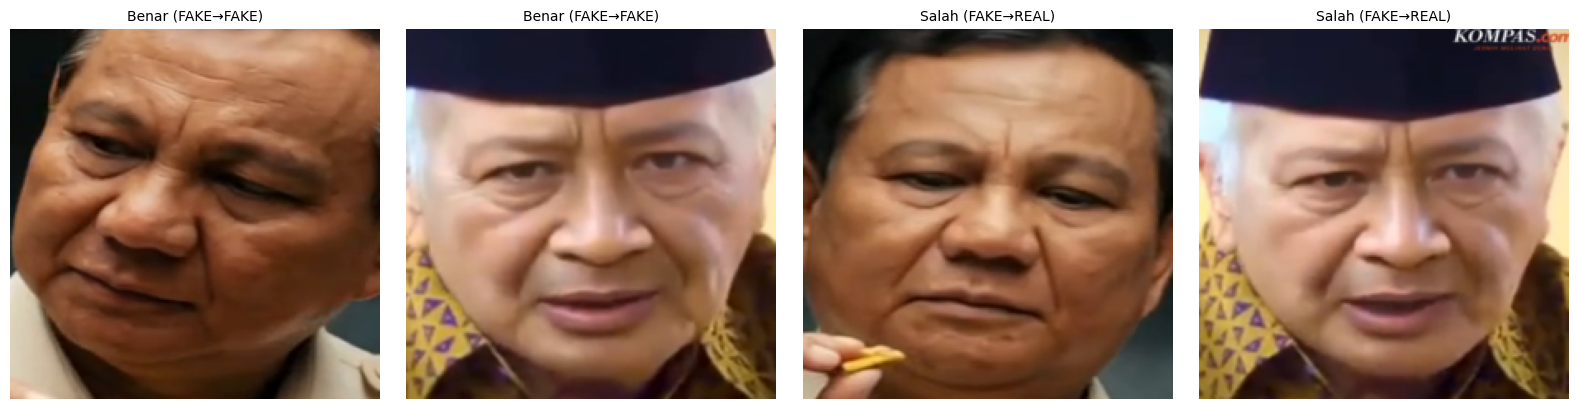

In [ ]:
pilihan_tp = [151, 252]
pilihan_fn = [150, 250]

selected = pilihan_tp + pilihan_fn
titles = ['Benar (FAKE→FAKE)']*len(pilihan_tp) + ['Salah (FAKE→REAL)']*len(pilihan_fn)

fig, axes = plt.subplots(1, len(selected), figsize=(4*len(selected), 4))

for ax, idx, title in zip(axes, selected, titles):
    img = all_faces[idx].cpu().numpy().transpose(1, 2, 0)
    img = std * img + mean
    img = np.clip(img, 0, 1)
    ax.imshow(img)
    ax.set_title(title, fontsize=10)
    ax.axis('off')

plt.tight_layout()
plt.savefig('contoh_frame_klasifikasi.png', dpi=300, bbox_inches='tight')
plt.show()